# Использование машинного обучения для создания рекомендательной системы онлайн-магазина.

## Введение.

Проект выполнен в качестве дипломной работы курса "Специалист по машинному обучению на табличных данных" онлайн-платформы Skillfactory и представляет из себя пример создания и развёртывания рекомендательной системы на сайте онлайн-ритейлера, основанной на модели машинного обучения. Исходные данные и некоторые другие условия для проекта были заранее предоставлены Skillfactory. Проект включает в себя следующие этапы: постановку задачи, исследование предоставленных исходных данных, создание факторов для модели, выбор наиболее подходящей модели машинного обучения, обучение и контроль качества модели, создание минимального работающего прототипа и контейнеризация итогового сервиса в Docker. Работа выполнена в Python 3.12.4.

In [1]:
#Используемые библиотеки:
import pandas as pd
import numpy as np
import networkx as nx
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from scipy.sparse import csr_matrix
import implicit
from implicit.bpr import BayesianPersonalizedRanking
from xgboost import XGBClassifier

c:\Users\New\Desktop\Data Science\Project_Diploma\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Постановка задачи.

### Бизнес-постановка задачи
С точки зрения бизнеса, внедрение рекомендательной системы нацелено на **увеличение выручки интернет-магазина** за счет роста следующих ключевых метрик (KPI):
1. **Конверсия (Conversion Rate, CR):** Превращение пассивных просмотров товаров (`view`) в целевые действия — добавление в корзину (`addtocart`) и совершение покупки (`transaction`).
2. **Средний чек (Average Order Value, AOV):** Кросс-продажи сопутствующих товаров, которые могут заинтересовать пользователя на основе его текущего поведения.
3. **Удержание клиентов (Customer Retention & LTV):** Персонализированный опыт повышает лояльность пользователей, заставляя их возвращаться на платформу повторно.

**Основная бизнес-цель:** Спроектировать алгоритм, который для каждого пользователя в реальном времени формирует персональную подборку из **3 товаров**, максимизирующую вероятность совершения покупки.

### Обоснование выбора метрики Precision@3
Для оценки качества моделей выбрана метрика **Precision@3 (точность в топ-3 рекомендациях)**. Выбор обусловлен спецификой интерфейса и паттернов поведения пользователей:

1. **Ограниченность внимания и UI:** На экранах мобильных устройств или в промо-блоках веб-сайта пользователь без скроллинга видит ограниченное число позиций (обычно топ-3). Нам критически важно, чтобы именно эти элементы были максимально релевантны.
2. **Нечувствительность к порядку внутри топ-3:** В пределах компактного UI-блока из трех товаров пользователь воспринимает их практически одновременно. Поэтому использование ранговых метрик (например, NDCG@3 или MAP@3) здесь избыточно — бизнес-ценность любой покупки из топ-3 одинакова.
3. **Прямая интерпретация для бизнеса:** Метрика показывает долю успешных рекомендаций. Например, $Precision@3 = 33.3\%$ означает, что в среднем каждый третий показ блока рекомендаций приводит к взаимодействию (клику/покупке), что позволяет легко прогнозировать экономический эффект от внедрения.

Математически метрика для пользователя $u$ рассчитывается как:
$$Precision@3(u) = \frac{|\text{Релевантные товары среди топ-3 рекомендованных}|}{3}$$
Итоговая метрика по всему датасету — это усредненное значение $Precision@3$ по всем пользователям из валидационной выборки.

## Получение, описание и очистка исходных данных.

В основе любой модели машинного обучения, работающей с онлайн-продажами, лежат уже имеющиеся данные об истории взаимодействий пользователей с сервисом - clickstream data. В данном кейсе эти данные уже были заранее собраны и лежат в файле event_data.csv.zip. Загрузим их в Pandas:

In [2]:
event_data = pd.read_csv('data/events.csv')
event_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   timestamp      2756101 non-null  int64  
 1   visitorid      2756101 non-null  int64  
 2   event          2756101 non-null  str    
 3   itemid         2756101 non-null  int64  
 4   transactionid  22457 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


Мы имеем дело с почти 2.76 миллионами уникальных взаимодействий пользователей с веб-сервисом заказчика (далее - ивентов), которые, однако, описываются всего лишь пятью признаками:

1. *timestamp* - Дата и время ивента.
2.  *visitorid* - Идентификатор пользователя (далее - юзера).
3. *event* - Тип ивента.
4. *itemid* - Идентификатор товара (марки товара, а не конкретного продаваемого экземпляра).
5. *transactionid* - Идентификатор траназакции, если товар был куплен.

Ключом к пониманию смысла этих данных является признак типа ивента. Посмотрим, какие именно категории ивентов описываются в нашем датасете:

In [3]:
print(event_data['event'].unique())

<StringArray>
['view', 'addtocart', 'transaction']
Length: 3, dtype: str


Ивент может представлять из себя просмотр товара пользователем - *view*, добавление его в корзину - *addtocart*, и собственно покупку - *transaction*. Эта информация имеет для нас ключевую ценность, ведь задача, которую мы решаем, может быть сведена к максимизации конверсии просмотра в покупку (вероятности, что за просмотром определённого товара последует его покупка) для среднего юзера. Для удобства будущей работы с категориями ивентов можно сразу же представить их с помощью трёх one-hot encoding колонок:

In [4]:
event_data['view'] = event_data['event'].map(lambda s: 1 if s=='view' else 0)
event_data['addtocart'] = event_data['event'].map(lambda s: 1 if s=='addtocart' else 0)
event_data['transaction'] = event_data['event'].map(lambda s: 1 if s=='transaction' else 0)

Признак даты и времени ивентов должен являться кладезем информации о поведении юзеров и динамике ивентов, но прежде, чем начать с ним работать, его нужно представить в корректном для него формате. Удостоверимся, что корректным форматом в данном случае является миллисекундный формат *datetime64[ms]*, проверив, что после конверсии в него получается правдоподобный диапазон дат:

In [5]:
time_test = event_data['timestamp'].astype('datetime64[ms]')
print(f'Исследуемые ивенты произошли в диапазоне дат между {time_test.min().round('s')} и {time_test.max().round('s')}')

Исследуемые ивенты произошли в диапазоне дат между 2015-05-03 03:00:04 и 2015-09-18 02:59:48


In [6]:
#Диапазон дат выглядит правдоподобно, можно смело конвертировать признак в миллисекундный формат:
event_data['timestamp'] = event_data['timestamp'].astype('datetime64[ms]')

Подавляющее большинство значений признака *transactionid* являютя пропусками. Однако ничего аномального в этом нет - очевидно, что у ивента, не являющегося транзакцией (покупкой), не может быть идентификатора транзакции. Проверим, совпадает ли количество пропущенных значений *transactionid* c количеством ивентов в датасете, не являющихся транзакциями (являющихся просмотром товара или добавлением его в корзину):

In [7]:
missing = event_data['transactionid'].isna().sum()
not_transactions = event_data['view'].sum() + event_data['addtocart'].sum()

print(missing==not_transactions)

True


Действительно, количество пропущенных значений *transactionid* совпадает с количеством ивентов, не являющихся транзакциями, а значит, все пропуски в этом признаке являются естественными и не нуждаются в какой-либо обработке.

Данные о свойствах самих товаров, представленных на сайте, имеют большой объём и содержатся в двух CSV-файлах. Загрузим их в Pandas и объединим:

In [8]:
item_properties = pd.concat(objs=[pd.read_csv('data/item_properties_part1.csv'), pd.read_csv('data/item_properties_part2.csv')])
item_properties.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 20275902 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Non-Null Count     Dtype
---  ------     --------------     -----
 0   timestamp  20275902 non-null  int64
 1   itemid     20275902 non-null  int64
 2   property   20275902 non-null  str  
 3   value      20275902 non-null  str  
dtypes: int64(2), str(2)
memory usage: 773.5 MB


Полученный датасет имеет четыре столбца:

1. *timestamp* - время обновления значения свойства. Одни и те же свойства одних и тех же товаров могут меняться с течением времени. Самое очевидное - свойство, показывающее доступен ли товар на складе в данный момент времени или нет.
2. *itemid* - идентификатор товара.
3. *property* - название свойства товара. Все названия, кроме доступности товара на складе (avaliability) и идентификатора категории (categoryid) захешированы и нечитаемы человеком.
4. *value* - значение свойства товара. Как и их названия, все свойства товаров кроме доступности на складе и идентификатора категории захешированы.

Как видно, несмотря на малое количество столбцов, данные о свойствах товаров представляют из себя довольно сложную, обладающую временным измерением, структуру. Для того, чтобы даже начать работать с ними, их необходимо подвергнуть существенному упрощению. Главное, что нужно сделать - превратить свойства товаров из объектов (строк таблицы) в признаки (её столбцы), по сути "сплющивая" наши данные и избавляя их от совершенно ненужного второго уровня адресации. Однако работать потенциально со многими десятками или сотнями признаков было бы чрезвычайно непрактично или даже невозможно. Поэтому я решил ограничиться работой с 20 свойствами, наиболее представленными среди всех товаров (предположив, что для каждого товара определены только несколько из всех возможных свойств). Для того, чтобы отличить настоящие наиболее широко представленные среди всех товаров свойства от наиболее часто обновляемых свойств, мы должны ненадолго избавиться от временного измерения:

In [9]:
item_properties['timestamp'] = item_properties['timestamp'].astype('datetime64[ms]')
item_properties['timestamp'].value_counts()

timestamp
2015-05-10 03:00:00    3012756
2015-05-31 03:00:00    2620101
2015-06-28 03:00:00    2368972
2015-05-24 03:00:00    1815598
2015-06-07 03:00:00    1686681
2015-08-16 03:00:00    1488244
2015-05-17 03:00:00    1027889
2015-06-14 03:00:00     755965
2015-07-12 03:00:00     593657
2015-09-13 03:00:00     583018
2015-08-23 03:00:00     571339
2015-09-06 03:00:00     566183
2015-07-19 03:00:00     563575
2015-08-09 03:00:00     542778
2015-08-30 03:00:00     532586
2015-08-02 03:00:00     529315
2015-07-26 03:00:00     519460
2015-07-05 03:00:00     497785
Name: count, dtype: int64

In [10]:
defined_by_june = item_properties[item_properties['timestamp'] <= '2015-05-31 03:00:00']
print(f'Около {round((defined_by_june.shape[0] / item_properties.shape[0]), 2)*100} % всех свойств товаров были определены к 1 июня 2015 года.')

Около 42.0 % всех свойств товаров были определены к 1 июня 2015 года.


In [11]:
top_20_properties = defined_by_june['property'].value_counts().keys()[:20]
top_20_properties

Index(['888', '790', 'available', 'categoryid', '283', '6', '776', '678',
       '364', '159', '764', '112', '917', '202', '839', '227', '698', '689',
       '28', '928'],
      dtype='str', name='property')

Код в ячейке выше посчитал 20 наиболее часто встречающихся свойств среди всех товаров, рассматривая каждый из товаров на момент 31 мая 2015 года. Теперь можно обрезать наши данные о свойствах, оставив только этих 20 "победителей" и их историю изменений для каждого из товаров:

In [12]:
item_properties = item_properties[item_properties['property'].isin(top_20_properties)]
print(item_properties.shape[0])

13563669


Как видно, размер таблицы со свойствами уменьшился примерно на треть - с 20 миллионов строк до 13 с половиной миллионов. Что более важно, теперь в колонке property содержится всего 20 уникальных свойств, и её можно развернуть в 20 новых столбцов.

In [13]:
item_properties = item_properties.set_index(['timestamp', 'itemid', 'property']).unstack(level='property')
item_properties.columns = item_properties.columns.droplevel(0)
item_properties = item_properties.reset_index()
item_properties.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5108711 entries, 0 to 5108710
Data columns (total 22 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   timestamp   5108711 non-null  datetime64[ms]
 1   itemid      5108711 non-null  int64         
 2   112         417053 non-null   str           
 3   159         417053 non-null   str           
 4   202         448938 non-null   str           
 5   227         347492 non-null   str           
 6   28          172393 non-null   str           
 7   283         597419 non-null   str           
 8   364         476486 non-null   str           
 9   6           631471 non-null   str           
 10  678         481966 non-null   str           
 11  689         214225 non-null   str           
 12  698         289849 non-null   str           
 13  764         417053 non-null   str           
 14  776         574220 non-null   str           
 15  790         1790516 non-null  str          

Видно, что большинство значений для всех свойств являются пропусками. Это - естественное следствие того, что таблица определяет значения каждого свойства только в те моменты времени, когда они были изменены/заданы в первый раз. Чтобы получить датасет, содержащий значения свойств в каждый момент времени, необходимо совершить forward fill пропусков по значениям времени для каждого товара (заполнить каждый пропуск значением свойства, определённым для соотвествующего товара в последний момент времени, не являющийся пропуском), а затем просто удалить все пропуски, соответствующие времени до того, как соответствующее свойство товара было определено для него в первый раз.

In [14]:
item_properties = item_properties.sort_values(by=['itemid', 'timestamp']).reset_index(drop=True)

property_cols = [col for col in item_properties.columns if col not in ['item_id', 'timestamp']]

item_properties[property_cols] = (item_properties.groupby('itemid')[property_cols].ffill())

item_properties.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5108711 entries, 0 to 5108710
Data columns (total 22 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   timestamp   5108711 non-null  datetime64[ms]
 1   itemid      5108711 non-null  int64         
 2   112         4409131 non-null  str           
 3   159         4412097 non-null  str           
 4   202         3366576 non-null  str           
 5   227         2812099 non-null  str           
 6   28          1293983 non-null  str           
 7   283         4430109 non-null  str           
 8   364         4418495 non-null  str           
 9   6           4293641 non-null  str           
 10  678         4418040 non-null  str           
 11  689         1655378 non-null  str           
 12  698         2250665 non-null  str           
 13  764         4408624 non-null  str           
 14  776         4300738 non-null  str           
 15  790         4574243 non-null  str          

In [15]:
item_properties_ = item_properties.drop(labels=['28', '227', '689', '698', '839', '928'], axis=1).dropna(axis=0)
item_properties_.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 2506285 entries, 6 to 5108710
Data columns (total 16 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   timestamp   2506285 non-null  datetime64[ms]
 1   itemid      2506285 non-null  int64         
 2   112         2506285 non-null  str           
 3   159         2506285 non-null  str           
 4   202         2506285 non-null  str           
 5   283         2506285 non-null  str           
 6   364         2506285 non-null  str           
 7   6           2506285 non-null  str           
 8   678         2506285 non-null  str           
 9   764         2506285 non-null  str           
 10  776         2506285 non-null  str           
 11  790         2506285 non-null  str           
 12  888         2506285 non-null  str           
 13  917         2506285 non-null  str           
 14  available   2506285 non-null  str           
 15  categoryid  2506285 non-null  str           
dty

In [16]:
item_properties = item_properties_

Теперь вернёмся к данным об ивентах и обогатим информацию о каждом ивенте свойствами, которыми вовлечённый в него товар обладал в момент ивента. Так как соединение датасетов производится не по точному совпадению моментов времени, а по моменту последнего изменения свойств товара, предвшевствовашему ивенту, необходимо вопользоваться _pd.merge_asof_ вместо обычного объединения датафреймов. После соединения датафреймов мы, однако, можем получить новые пропуски, связанные с тем, что самые ранние ивенты, связанные с определёнными товарами, могли произойти до первого определения части их свойств. Чтобы избежать утечки данных, придётся удалить и их, даже если при этом придётся потерять информацию о части ивентов.

In [17]:
item_properties['itemid'].info()

<class 'pandas.Series'>
Index: 2506285 entries, 6 to 5108710
Series name: itemid
Non-Null Count    Dtype
--------------    -----
2506285 non-null  int64
dtypes: int64(1)
memory usage: 38.2 MB


In [18]:
event_data = event_data.sort_values(by='timestamp')
item_properties = item_properties.sort_values(by='timestamp')
item_properties['itemid'] = item_properties['itemid'].astype(float)
event_data['itemid'] = event_data['itemid'].astype(float)

event_data = pd.merge_asof(
    event_data,
    item_properties,
    on='timestamp',
    by='itemid',
    direction='backward'
)

event_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 22 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   timestamp      2756101 non-null  datetime64[ms]
 1   visitorid      2756101 non-null  int64         
 2   event          2756101 non-null  str           
 3   itemid         2756101 non-null  float64       
 4   transactionid  22457 non-null    float64       
 5   view           2756101 non-null  int64         
 6   addtocart      2756101 non-null  int64         
 7   transaction    2756101 non-null  int64         
 8   112            1241005 non-null  str           
 9   159            1241005 non-null  str           
 10  202            1241005 non-null  str           
 11  283            1241005 non-null  str           
 12  364            1241005 non-null  str           
 13  6              1241005 non-null  str           
 14  678            1241005 non-null  str         

Даже сейчас в данных всё ещё остаются пропуски. Посмотрим на их количество.

Как видно, пропусков одинаковое количество во всех колонках со свойствами товаров, что наводит на мысль, что все они находятся в одних и тех же строках таблицы. Проверим, так ли это:

In [19]:
temp = event_data.drop(labels=['transactionid'], axis=1)
temp[temp.isna().any(axis=1)].info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 1515096 entries, 0 to 2756085
Data columns (total 21 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   timestamp    1515096 non-null  datetime64[ms]
 1   visitorid    1515096 non-null  int64         
 2   event        1515096 non-null  str           
 3   itemid       1515096 non-null  float64       
 4   view         1515096 non-null  int64         
 5   addtocart    1515096 non-null  int64         
 6   transaction  1515096 non-null  int64         
 7   112          0 non-null        str           
 8   159          0 non-null        str           
 9   202          0 non-null        str           
 10  283          0 non-null        str           
 11  364          0 non-null        str           
 12  6            0 non-null        str           
 13  678          0 non-null        str           
 14  764          0 non-null        str           
 15  776          0 non-null        

Код в ячейках выше показывает, что товары, у которых не определено значение свойства 112, на 100% совпадают с товарами, у которых не определены свойства 202, 6, и categoryid, и всего таких товаров 54311. Это не может быть совпадением и явно свидетельствует  о том, что у нас есть целая группа товаров, о свойствах которых у нас нет никакой информации. Всё, что можно сделать - подставить нули вместо значений свойств для этих товаров:

In [20]:
for col in event_data.columns:
    print(col+': '+str('00000000' in event_data[col]))

timestamp: False
visitorid: False
event: False
itemid: False
transactionid: False
view: False
addtocart: False
transaction: False
112: False
159: False
202: False
283: False
364: False
6: False
678: False
764: False
776: False
790: False
888: False
917: False
available: False
categoryid: False


In [21]:
property_cols = ['112', '159', '202', '283', '364', '6', '678', '764', '776', '790', '888', '917', 'available', 'categoryid']
event_data[property_cols] = event_data[property_cols].fillna('00000000')
event_data['transactionid'] = event_data['transactionid'].fillna(-1).astype(int)

event_data['visitorid'] = event_data['visitorid'].astype(float)
event_data['itemid'] = event_data['itemid'].astype(float)

event_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 22 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   timestamp      2756101 non-null  datetime64[ms]
 1   visitorid      2756101 non-null  float64       
 2   event          2756101 non-null  str           
 3   itemid         2756101 non-null  float64       
 4   transactionid  2756101 non-null  int64         
 5   view           2756101 non-null  int64         
 6   addtocart      2756101 non-null  int64         
 7   transaction    2756101 non-null  int64         
 8   112            2756101 non-null  str           
 9   159            2756101 non-null  str           
 10  202            2756101 non-null  str           
 11  283            2756101 non-null  str           
 12  364            2756101 non-null  str           
 13  6              2756101 non-null  str           
 14  678            2756101 non-null  str         

Категории, к которым относятся товары, имеют собственную иерархическую структуру, закодированную в отдельном CSV-файле. Попробуем восстановить её.

In [22]:
category_tree = pd.read_csv('data/category_tree.csv')
category_tree.info()

<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


Товары могут относиться к одной из 1669 категорий, 1644 из которых являются вложенными в другую категорию. 25 категорий (1669 - 1644) не имеют родительской категории, так как сами находятся в корне всего дерева. Посмотрим, сколько уровней вложенности могут иметь категории, и на каком находится каждая конкретная их них:

In [23]:
parent_map = category_tree.set_index('categoryid')['parentid'].to_dict()

def get_depth(node_id):
    depth = 1
    current = parent_map.get(node_id)
    while pd.notna(current):
        depth += 1
        current = parent_map.get(current)
    return depth

category_tree['categorylevel'] = category_tree['categoryid'].apply(get_depth)
print(f"Дерево категорий содержит {category_tree['categorylevel'].max()} уровней.")

Дерево категорий содержит 6 уровней.


Итак, категории в иерархии могут располагаться на 6 уровнях. Посмотрим, сколько категорий содержит каждый из них:

In [24]:
for n in range(1, 7):
    print(f"{n} уровень дерева содержит {category_tree[category_tree['categorylevel']==n].shape[0]} категорий.")

1 уровень дерева содержит 25 категорий.
2 уровень дерева содержит 174 категорий.
3 уровень дерева содержит 702 категорий.
4 уровень дерева содержит 665 категорий.
5 уровень дерева содержит 90 категорий.
6 уровень дерева содержит 13 категорий.


Как видно, уже на втором уровне дерева содержится больше полутора сотен отдельных категорий, что делает визуализацию даже верхних уровней дерева нецелесообразной. Можно, однако, посмотреть, как распределены категории второго уровня средни 25 корневых категорий, что и будет сделано ниже. С другой стороны, следует обратить внимание на шестой, самый нижний уровень дерева - в нём всего 13 категорий, что значит, что они соответствуют какому-то набору узкоспециализированных товаров и, скорее всего, все принадлежат к одной-двум категориям пятого уровня.

In [25]:
category_tree[category_tree['categorylevel']==2]['parentid'].value_counts()

parentid
250.0     31
1482.0    13
1224.0    11
1490.0    10
653.0     10
1579.0    10
1600.0    10
378.0      9
395.0      9
140.0      9
679.0      8
755.0      8
1698.0     7
1532.0     6
791.0      5
859.0      3
431.0      3
1692.0     3
803.0      2
1057.0     2
1452.0     2
1394.0     1
659.0      1
1182.0     1
Name: count, dtype: int64

Видно, что около 15% (31 из 174) всех категорий второго уровня принадлежат к коренвой категории под номером 250. Это наблюдение может пригодиться в дальнейшем при разведывательном анализе.

Используем рекурсивный цикл, чтобы пройтись по дереву снизу вверх и сопоставить каждой категории корневую категорию, к которой она принадлежит (корневым категориям сопоставим самих себя).

In [26]:
#Создаем направленный граф из связей parent -> child
#Важно: инвертируем связь (от родителя к ребенку), чтобы легко находить корни
G = nx.from_pandas_edgelist(
    category_tree.dropna(subset=['parentid']),
    source='parentid',
    target='categoryid',
    create_using=nx.DiGraph()
)

#Находим корни (у них нет входящих связей в графе)
roots = [n for n, d in G.in_degree() if d == 0]

#Для каждого корня находим все зависимые подкатегории (потомков)
root_mapping = {}
for root in roots:
    descendants = nx.descendants(G, root)
    for desc in descendants:
        root_mapping[desc] = root
    root_mapping[root] = root

category_tree['rootcategory'] = category_tree['categoryid'].map(root_mapping)
category_tree['rootcategory'] = category_tree['rootcategory'].fillna(category_tree['categoryid'])

In [27]:
subroot_mapping = {}

for root in roots:

    paths = nx.single_source_shortest_path(G, root)

    for node, path in paths.items():

        if len(path) == 1:# Это сам корень (уровень 0)
            subroot_mapping[node] = -1
        elif len(path) == 2:
            subroot_mapping[node] = node
        else:
            # Для всех уровней глубже берем path[1] - ссылку на "подкорень" (path[0] - ссылка на сам корень)
            subroot_mapping[node] = path[1]

category_tree['subrootcategory'] = category_tree['categoryid'].map(subroot_mapping)
category_tree['subrootcategory'] = category_tree['subrootcategory'].fillna(-1).astype(int)

Теперь добавим информацию о корневой категории, категории второго уровня и уровне вложенности для каждой категории товаров в наш основной датасет.

In [28]:
category_tree = category_tree.reset_index(drop=True).astype('str')
event_data = pd.merge(event_data, category_tree, on='categoryid', how='left').drop(labels=['parentid'], axis=1).fillna(-1)
event_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 25 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   timestamp        2756101 non-null  datetime64[ms]
 1   visitorid        2756101 non-null  float64       
 2   event            2756101 non-null  str           
 3   itemid           2756101 non-null  float64       
 4   transactionid    2756101 non-null  int64         
 5   view             2756101 non-null  int64         
 6   addtocart        2756101 non-null  int64         
 7   transaction      2756101 non-null  int64         
 8   112              2756101 non-null  str           
 9   159              2756101 non-null  str           
 10  202              2756101 non-null  str           
 11  283              2756101 non-null  str           
 12  364              2756101 non-null  str           
 13  6                2756101 non-null  str           
 14  678          

На этом первичная обработка и описание данных закончены.

## Разведывательный анализ данных.

In [29]:
print(f'У нас есть {event_data['visitorid'].nunique()} уникальных юзеров и {event_data['itemid'].nunique()} марок товаров в {event_data['categoryid'].nunique()} разных категориях, с которыми они взаимодействовали.')

У нас есть 1407580 уникальных юзеров и 235061 марок товаров в 1094 разных категориях, с которыми они взаимодействовали.


interactions_per_user = event_data[['visitorid', 'view', 'addtocart', 'transaction']].groupby('visitorid').agg(sum)
print(f'Средний юзер просмотрел {interactions_per_user['view'].mean():.2f} товаров, добавил в корзину {interactions_per_user['addtocart'].mean():.2f}, а купил {interactions_per_user['transaction'].mean():.2f} товаров.')

C:\Users\New\AppData\Local\Temp\ipykernel_3320\1390240353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=event_data, x='event', palette='viridis')


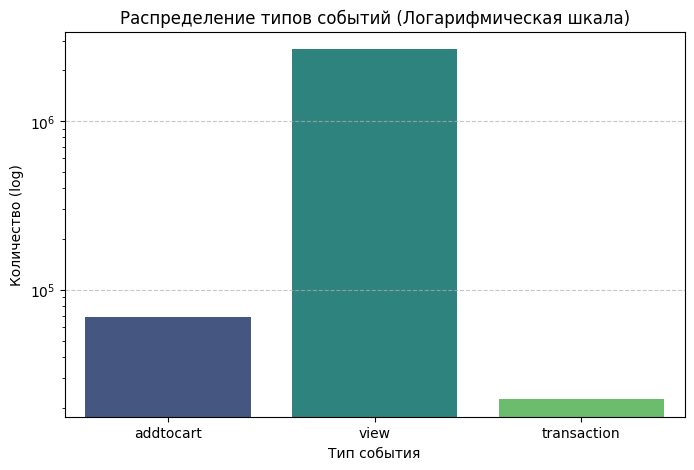

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=event_data, x='event', palette='viridis')
plt.title('Распределение типов событий (Логарифмическая шкала)')
plt.yscale('log')
plt.xlabel('Тип события')
plt.ylabel('Количество (log)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Как видно, выборка чрезвычайно несбалансирована - трансзакции составляют всего около одного процента от общего числа событий.

In [31]:
for i in range(5):
    user_counts = event_data['visitorid'].value_counts()
    item_counts = event_data['itemid'].value_counts()

    event_data = event_data[
        (event_data['visitorid'].isin(user_counts[user_counts > 5].index)) &
        (event_data['itemid'].isin(item_counts[item_counts > 5].index))
    ]

print(event_data.shape[0])

650942


In [32]:
user_counts = event_data['visitorid'].value_counts().reset_index()
user_counts.columns = ['visitorid', 'interaction_count']

upper_bound = 20

active_users = user_counts[user_counts['interaction_count'] > upper_bound]

value = active_users['interaction_count'].sum() / event_data.shape[0]
value_2 = event_data[(event_data['event']=='transaction')&(event_data['visitorid'].isin(active_users['visitorid']))].shape[0] / event_data[event_data['event']=='transaction'].shape[0]
print(f'{active_users.shape[0]} активных юзеров ответственны за {round(value*100, 2)}% всех ивентов, включая {round(value_2*100, 2)}% всех покупок.')

4823 активных юзеров ответственны за 43.63% всех ивентов, включая 58.03% всех покупок.


In [33]:
item_counts = event_data['itemid'].value_counts().reset_index()
item_counts.columns = ['itemid', 'interaction_count']

upper_bound = 100

popular_items = item_counts[item_counts['interaction_count'] > upper_bound]

value = popular_items['interaction_count'].sum() / event_data.shape[0]
value_2 = event_data[(event_data['event']=='transaction')&(event_data['itemid'].isin(popular_items['itemid']))].shape[0] / event_data[event_data['event']=='transaction'].shape[0]
print(f'{popular_items.shape[0]} самых популярных товаров являются предметом {round(value*100, 2)}% всех ивентов, включая {round(value_2*100, 2)}% всех покупок.')

702 самых популярных товаров являются предметом 18.4% всех ивентов, включая 20.31% всех покупок.


Код выше показывает, что как склонность юзеров покупать товары, так и популярность товаров среди юзеров распределены далеко не равномерно - у нас есть сравнительно небольшие наборы как юзеров, так и товаров, ответственные за львиные доли всех покупок. Из этого можно сделать предварительный вывод, что для эффективного создания рекомендательной системы в данном кейсе нужно будет учитывать, как профили юзеров, так и свойства товаров.

In [34]:
viewed_items = event_data[event_data['event']=='view']
viewed_items['itemid'].value_counts()

itemid
461686.0    1218
9877.0       828
257040.0     770
241555.0     695
119736.0     642
            ... 
373490.0       1
63406.0        1
204235.0       1
71952.0        1
47930.0        1
Name: count, Length: 28601, dtype: int64

In [35]:
bought_items = event_data[event_data['event']=='transaction']
bought_items['itemid'].value_counts()

itemid
461686.0    107
119736.0     97
213834.0     76
445351.0     38
420960.0     30
           ... 
142881.0      1
389860.0      1
302559.0      1
312594.0      1
342659.0      1
Name: count, Length: 9165, dtype: int64

Код выше показывает, что самые просматриваемые и самые покупаемые товары практически не пересекаются друг с другом - из 10 самых просматриваемых товаров только один - товар под номером 461686 входит в топ-10 по покупаемости. Это показывает, что в настоящее время система рекомендаций практически не работает по назначению. Также заметим, что тремя самыми покупаемыми видами товаров являются товары под номерами 461686, 119736, и 213834. Эти три товара в дальнейшем можно использовать в каачестве фолбека на случай холодного старта - рекомендовать их новым посетителям сайта, о поведении или вкусах которых ешё ничего не известно.

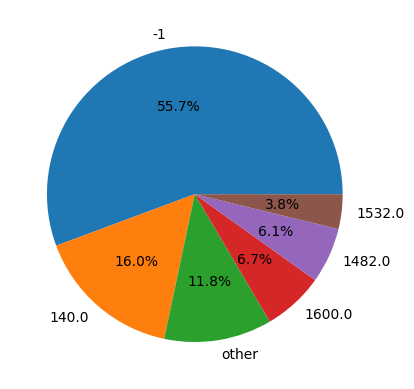

In [36]:
top_five_root_categories = event_data['rootcategory'].value_counts().keys()[:5]
categories_simplified = event_data['rootcategory'].apply(lambda cat: cat if cat in top_five_root_categories else 'other')

fig, ax = plt.subplots()
fracs = categories_simplified.value_counts()
labels = fracs.keys()

ax.pie(fracs, labels=labels, autopct='%1.1f%%')

plt.show()

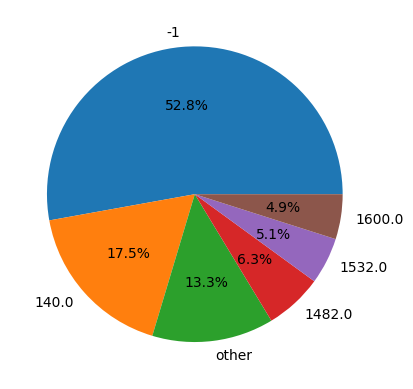

In [37]:
top_five_root_categories = bought_items['rootcategory'].value_counts().keys()[:5]
categories_simplified = bought_items['rootcategory'].apply(lambda cat: cat if cat in top_five_root_categories else 'other')

fig, ax = plt.subplots()
fracs = categories_simplified.value_counts()
labels = fracs.keys()

ax.pie(fracs, labels=labels, autopct='%1.1f%%')

plt.show()

Похоже, товары, принадлежащие к корневой категории 140, пользуются огромным успехом как в привлечении просмотров, так и в конверсии этих просмотров в покупки. Возможно, стоит вынести принадлежность товара к этой категории в отдельный бинарный признак.

In [38]:
event_data['category140'] = event_data['rootcategory'].map(lambda x: 1 if x==140 else 0)

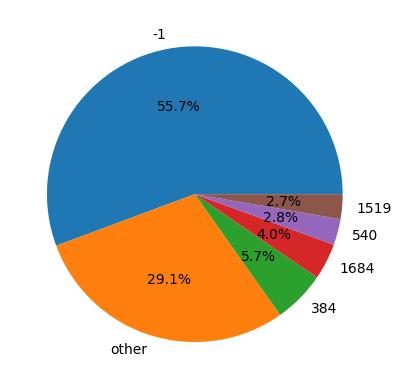

In [39]:
top_five_subroot_categories = event_data['subrootcategory'].value_counts().keys()[:5]
categories_simplified = event_data['subrootcategory'].apply(lambda cat: cat if cat in top_five_subroot_categories else 'other')

fig, ax = plt.subplots()
fracs = categories_simplified.value_counts()
labels = fracs.keys()

ax.pie(fracs, labels=labels, autopct='%1.1f%%')

plt.show()

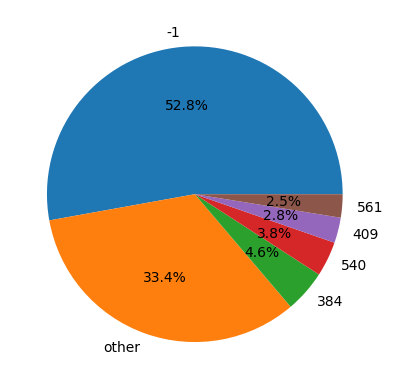

In [40]:
top_five_subroot_categories = bought_items['subrootcategory'].value_counts().keys()[:5]
categories_simplified = bought_items['subrootcategory'].apply(lambda cat: cat if cat in top_five_subroot_categories else 'other')

fig, ax = plt.subplots()
fracs = categories_simplified.value_counts()
labels = fracs.keys()

ax.pie(fracs, labels=labels, autopct='%1.1f%%')

plt.show()

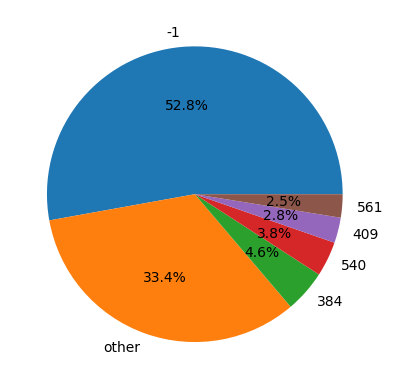

In [41]:
top_five_subroot_categories = bought_items['subrootcategory'].value_counts().keys()[:5]
categories_simplified = bought_items['subrootcategory'].apply(lambda cat: cat if cat in top_five_subroot_categories else 'other')

fig, ax = plt.subplots()
fracs = categories_simplified.value_counts()
labels = fracs.keys()

ax.pie(fracs, labels=labels, autopct='%1.1f%%')

plt.show()

А вот в распределении категорий второго уровня, как видно из двух вышеприведённых диаграмм, никакой особой закономерности не наблюдается.

Выделим из признака timestamp месяц, день, день недели, и час ивента как отдельные признаки.

In [42]:
event_data['month'] = event_data['timestamp'].map(lambda x: x.month)
event_data['dayofmonth'] = event_data['timestamp'].map(lambda x: x.day)
event_data['dayofweek'] = event_data['timestamp'].dt.day_name()
event_data['hour'] = event_data['timestamp'].map(lambda x: x.hour)

Как мы уже выяснили на этапе знакомства с данными, все они были собраны за период с мая по сентябрь 2015 года, так что сезонности в них обнаружить не получится. Однако посмотреть на распределение событий по месяцам (а для нагдядности можно и по полу-месяцам) не помешает - хотя бы для того, чтоьы удостовериться, что мы не имеем дело со смещёнными по времени данными.

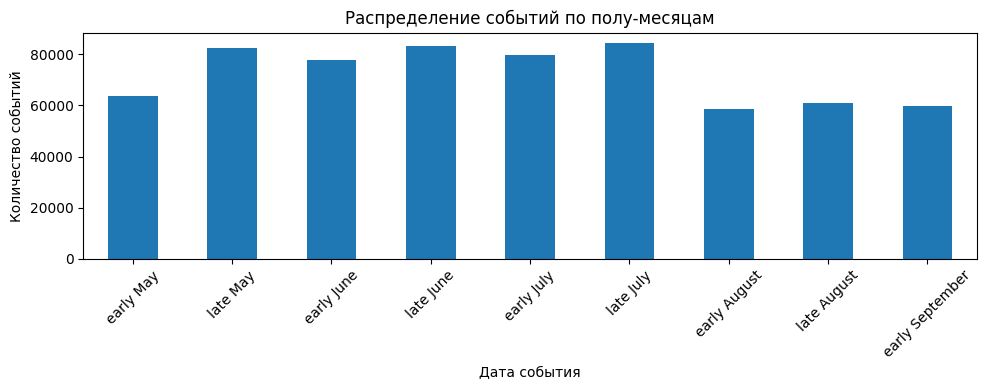

In [43]:
def half_month_label(dt):
    half = "early" if dt.day <= 15 or dt.month == 9 else "late"
    return f"{half} {dt.strftime('%B')}"

labels = event_data['timestamp'].map(half_month_label)

counts = labels.value_counts()

ordered = (
    pd.DataFrame({"date": event_data['timestamp'], "label": labels})
      .sort_values("date")
      .drop_duplicates("label")
)

counts = counts.reindex(ordered["label"])

plt.figure(figsize=(10, 4))
counts.plot(kind="bar")

plt.ylabel("Количество событий")
plt.xlabel("Дата события")
plt.title("Распределение событий по полу-месяцам")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

События распределены по месяцам более-менее одинаково, падение их числа с раннего августа, скорее всего, является случайным событием. Малое число событий в раннем мае связано с тем, что данные начали собираться не с первого числа мая, а гораздо позже.

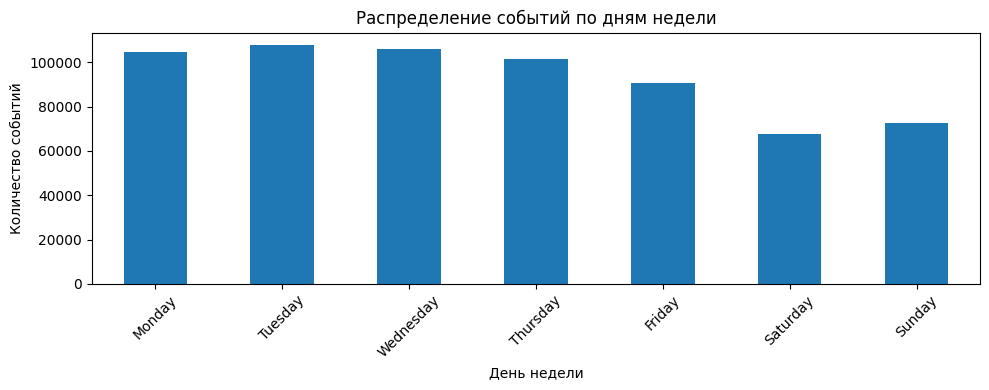

In [44]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
counts = event_data['dayofweek'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 4))
counts.plot(kind="bar")

plt.ylabel("Количество событий")
plt.xlabel("День недели")
plt.title("Распределение событий по дням недели")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

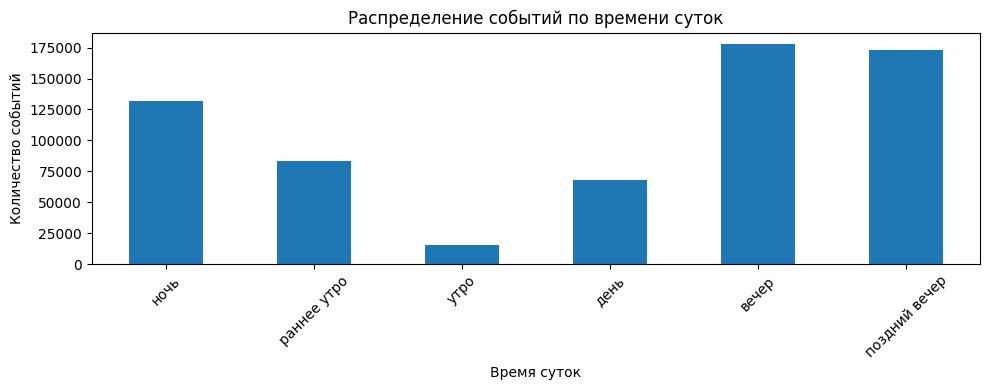

In [45]:
time_of_day_labels = {0:'ночь', 1:'ночь', 2:'ночь', 3:'ночь',
                      4:'раннее утро', 5:'раннее утро', 6:'раннее утро', 7:'раннее утро',
                      8:'утро', 9:'утро', 10:'утро', 11:'утро',
                      12:'день', 13:'день', 14:'день', 15:'день',
                      16:'вечер', 17:'вечер', 18:'вечер', 19:'вечер',
                      20:'поздний вечер', 21:'поздний вечер', 22:'поздний вечер', 23:'поздний вечер'}

event_data['timeofday'] = event_data['hour'].map(time_of_day_labels)

counts = event_data['timeofday'].value_counts()

ordered = (
    pd.DataFrame({"time": event_data['timestamp'], "label": event_data['timeofday']})
      .sort_values("time")
      .drop_duplicates("label")
)

counts = counts.reindex(ordered["label"])

plt.figure(figsize=(10, 4))
counts.plot(kind="bar")

plt.ylabel("Количество событий")
plt.xlabel("Время суток")
plt.title("Распределение событий по времени суток")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

По будним дням недели события распределены почти одинаково, но в выходные, а также в предшествующую им пятницу, заметно уменьшаются в объёме. С другой стороны, очень сильная неравномерность наблюдается в распределении событий по времени суток - почти никто не покупает товары между 8 утра и полуднем (утро), и мало кто - ранним утром и днём. Возможно, такая неравномерность свидетельствует, что имеет смысл подумать о дополнительных способах привлечения пользователей в утренне-дневные часы?

In [46]:
from sklearn.feature_selection import mutual_info_classif

category_cols = ['112', '202', '283', '364',
        '6', '678', '764', '776', '790', '888', '917', 'available',
       'rootcategory', 'subrootcategory', 'categoryid', 'category140', 'month',
       'dayofmonth', 'dayofweek', 'timeofday', 'hour']

X = event_data[category_cols].copy()
for column in X.columns:
    X[column] = X[column].astype('category').cat.codes
y = event_data['transaction']

mi_scores = mutual_info_classif(X, y, discrete_features=True)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(mi_results)

888                0.012844
364                0.012403
917                0.012319
776                0.012149
283                0.012094
202                0.011698
790                0.004568
6                  0.002627
categoryid         0.002317
678                0.002231
subrootcategory    0.001038
hour               0.000758
timeofday          0.000600
available          0.000417
rootcategory       0.000333
dayofweek          0.000220
month              0.000086
dayofmonth         0.000068
764                0.000041
112                0.000041
category140        0.000000
dtype: float64


К сожалению, большинство свойств товаров не оказывают заметного влияния на вероятность его покупки. Самыми значимыми кажутся свойства 888, 364, 917, 776, и 283. Как ни странно, ни категория товара, ни его доступность на складе не показывают видимой корреляции с вероятностью успешной покупки.

Теперь перейдём от рассмотрения отдельных товаров и событий к рассмотрению пользовательских сессий. Для построения информации о сессиях воспользуемся оконной функцией diff. Будем считать, что пользователь закрыл вкладку браузера с нашим сервисом и закончил сессию, если он не совершал никаких действий (ивентов) в течение 30 минут или дольше.

In [47]:
event_data = event_data.sort_values(by=['visitorid', 'timestamp'])

event_data['timediff'] = event_data.groupby('visitorid')['timestamp'].diff()

threshold = pd.Timedelta(minutes=30)
event_data['newsession'] = (event_data['timediff'] > threshold).astype(int)

event_data['sessionnumber'] = event_data.groupby('visitorid')['newsession'].cumsum()
event_data['sessionid'] = event_data['visitorid'].astype(str) + '_' + event_data['sessionnumber'].astype(str)

In [48]:
event_data['timediff'] = event_data['timediff'].fillna(pd.Timedelta(seconds=0))

In [49]:
session_data = event_data.groupby(['visitorid', 'sessionid']).agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max'),
    total_clicks=('itemid', 'count'),
    unique_items=('itemid', 'nunique'),
    viewed=('view', 'sum'),
    carted=('addtocart', 'sum'),
    bought=('transaction', 'sum'),
    interacted_items=('itemid', lambda x: list(x.unique()))
).reset_index()

session_data['duration_minutes'] = ((session_data['session_end'] - session_data['session_start']).dt.total_seconds() / 60).round(2)
print(f'За рассматриваемый промежуток времени произошло {session_data.shape[0]} сессий.')

За рассматриваемый промежуток времени произошло 179457 сессий.


Посмотрим на базовые статистики сессий.

In [50]:
print(session_data['duration_minutes'].max(), session_data['duration_minutes'].median(), session_data['duration_minutes'].mean().round(2))

723.26 0.21 8.2


In [51]:
print(session_data['viewed'].mean().round(), session_data['carted'].mean().round(), session_data['bought'].mean().round())

3.0 0.0 0.0


В среднем, пользовательская сессия на нашем сервисе длится 8 минут и 12 секунд (8.2 минуты). Самая короткая зарегистрированная сессия длилась всего 12 секунд (0.21 минуты), а самая длинная - больше двенадцати часов (723 минуты), но и то, и другое, скорее всего, являются выбросами, не отражающими какую-либо значимую долю от общего чила сессий. В подавляющем большинстве сессий пользователь просмотрел три товара, но ничего не добавил в корзину и не купил - следствие нормальной для этого типа задач несбалансированности классов, которую мы уже отметили выше.

Отдельно посмотрим на статистики для "успешных" сессий - таких, в которых пользователь купил хотя бы один товар.

In [52]:
sucessful_sessions = session_data[session_data['bought']>0]
sucessful_sessions.shape[0]

8678

In [53]:
print(sucessful_sessions['duration_minutes'].min(), sucessful_sessions['duration_minutes'].max(), sucessful_sessions['duration_minutes'].median())

0.0 723.26 19.37


In [54]:
print(sucessful_sessions['viewed'].mean().round(), sucessful_sessions['carted'].mean().round(), sucessful_sessions['bought'].mean().round())

8.0 2.0 2.0


Как видим, типичная "успешная" сессия длится более чем в два раза дольше типичной "неуспешной" - более 19 минут. Самые короткие успешные сессии имеют продолжительность в 0 секунд - это не ошибка, а следствие того, что существуют пользователи, купившие что-либо по прямой ссылке или со страницы поиска в Интернете, минуя стадию просмотра товаров. В среднем, пользователь просматривает за успешную сессию 8 товаров, но покупает только два из них, демонстрируя 25% среднюю конверсию просмотра в покупку. Это довольно низкое значение, которое имеет потенциал к повышению с помощью хорошей рекомендательной системы.

Теперь займёмся ранжированием пользователей по лояльности (количеству сессий, то есть тому, сколько раз они возвращались на сайт).

In [56]:
grouped_by_users = session_data.groupby('visitorid')
users_by_loyalty = grouped_by_users.agg('count')[['sessionid']].sort_values(by='sessionid', ascending=False)
users_by_loyalty.head(10)

,sessionid
visitorid,
316850.0,427
895999.0,412
825321.0,409
638482.0,326
518659.0,287
1126569.0,273
530559.0,269
85734.0,262
1165148.0,258


Как видим, самые лояльные пользователи возвращаются на сайт сотни раз - скорее всего, регулярно используя его для покупки чего-то необходимого для их собственной работы или бизнеса. Непонятно, однако, насколько большую долю они составляют от общего числа посетителей сайта. Чтобы это узнать, отсортируем пользователей по четырём категориям: посетили сайт всего один раз, посетили сайт несколько (меньше десяти) раз, посетили сайт десятки раз, и посетили сайт сотни раз.

In [57]:
one_time_clients = users_by_loyalty[users_by_loyalty['sessionid']==1].index
casual_clients = users_by_loyalty[(users_by_loyalty['sessionid']>=2)&(users_by_loyalty['sessionid']<10)].index
loyal_clients = users_by_loyalty[(users_by_loyalty['sessionid']>=10)&(users_by_loyalty['sessionid']<100)].index
very_loyal_clients = users_by_loyalty[users_by_loyalty['sessionid']>=100].index

print(one_time_clients.shape[0], casual_clients.shape[0], loyal_clients.shape[0], very_loyal_clients.shape[0])

14087 28328 2599 58


Как видим, подавляющее большинство посетителей использовали сайт менее сотни раз, из них около трети посетили сайт всего один раз, а около двух третей - от двух до девяти раз.

In [58]:
one_time_clients = session_data[session_data['visitorid'].isin(one_time_clients)]
casual_clients = session_data[session_data['visitorid'].isin(casual_clients)]
loyal_clients = session_data[session_data['visitorid'].isin(loyal_clients)]

In [60]:
for subset in [one_time_clients, casual_clients, loyal_clients]:
    print(subset['duration_minutes'].mean().round())

17.0
7.0
7.0


In [61]:
for subset in [one_time_clients, casual_clients, loyal_clients]:
    print(f'{round((subset[subset['duration_minutes']==0].shape[0] / subset.shape[0])*100)}%')

0%
46%
66%


Как ни странно, но юзеры, посетившие сайт всего один раз, в среднем проводят на нём около 17 минут, в то время как постоянные пользователи - около 7 минут. Также в примерно половине случаев постоянные посетители сайта проводят на нём меньше половины минуты - скорее всего, это значит, что они возвращаются на сайт только за определённым типом товара.

### Промежуточные выводы по дополненному EDA для построения модели:

1. **Экстремальный дисбаланс классов:** Покупки (`transaction`) составляют менее 1% от общего числа событий, в то время как просмотры (`view`) доминируют.
   * *Польза для модели:* При обучении классификатора (XGBoost) необходимо использовать взвешивание классов (`scale_pos_weight`) либо формировать обучающую выборку с помощью негативного семплирования (negative sampling), иначе модель будет всегда предсказывать отсутствие покупки.
2. **Временные паттерны (Суточная и недельная сезонность):** Наблюдается явный спад активности в ночные часы (с 0 до 5 утра) и пики в вечернее время. По дням недели активность распределена относительно равномерно, с небольшим снижением к выходным.
   * *Польза для модели:* Признаки `hour` и `day_of_week` станут сильными предикторами для контекстных рекомендаций (например, в выходные или ночью структура спроса может меняться).
3. **«Холодные» пользователи и товары:** В датасете присутствует длинный хвост пользователей и товаров с единичными взаимодействиями.
   * *Польза для модели:* Чистая коллаборативная фильтрация будет страдать от проблемы «холодного старта». Это обосновывает необходимость перехода к контентным методам и градиентному бустингу, способным использовать свойства товаров (`categoryid`, `available` и др.).
4. **Даже самые лояльные юзеры (100 сессий и более) обычно проводят на сайте менее минуты за сессию**, что является симптомом того, что и они в настоящее время покупают по одному товару за сессию.
   * *Польза для модели:* Имеется огромный простор для оптимизации рекомендаций для лояльных юзеров, учитывая что об их поведении собрано большое количество информации, что позволит эффективно использовать коллоборативную фильтрацию.

## Генерация факторов юзер-айтем

Для работы контентных моделей и XGBoost сгенерируем агрегированные матрицы признаков, которые отражают историю взаимодействия конкретного пользователя с конкретным товаром и категорией.

In [62]:
# Преобразуем колонки, если они еще строковые
event_data['view'] = event_data['view'].astype(int)
event_data['addtocart'] = event_data['addtocart'].astype(int)
event_data['transaction'] = event_data['transaction'].astype(int)

# 1. Агрегируем взаимодействия на паре user-item
user_item_features = event_data.groupby(['visitorid', 'itemid']).agg(
    user_item_view_count=('view', 'sum'),
    user_item_cart_count=('addtocart', 'sum'),
    user_item_trans_count=('transaction', 'sum'),
    user_item_last_timestamp=('timestamp', 'max')
).reset_index()

# 2. Добавляем глобальные признаки пользователя (User Profile)
user_features = event_data.groupby('visitorid').agg(
    user_total_views=('view', 'sum'),
    user_total_carts=('addtocart', 'sum'),
    user_total_txs=('transaction', 'sum'),
    user_unique_items=('itemid', 'nunique')
).reset_index()

# Рассчитаем конверсию пользователя
user_features['user_cart_to_view_ratio'] = user_features['user_total_carts'] / (user_features['user_total_views'] + 1)
user_features['user_purchase_ratio'] = user_features['user_total_txs'] / (user_features['user_total_views'] + 1)

# 3. Добавляем глобальные признаки товара (Item Profile)
item_features = event_data.groupby('itemid').agg(
    item_total_views=('view', 'sum'),
    item_total_carts=('addtocart', 'sum'),
    item_total_txs=('transaction', 'sum'),
    item_unique_users=('visitorid', 'nunique')
).reset_index()

# Рассчитаем популярность и конверсию товара
item_features['item_purchase_ratio'] = item_features['item_total_txs'] / (item_features['item_total_views'] + 1)

# 4. Объединяем всё в единый датасет факторов
features_df = user_item_features.merge(user_features, on='visitorid', how='left')
features_df = features_df.merge(item_features, on='itemid', how='left')

# Вычисляем относительные признаки (какую долю от всех своих действий юзер совершил с этим айтемом)
features_df['user_item_view_share'] = features_df['user_item_view_count'] / (features_df['user_total_views'] + 1)

# Целевая переменная: была ли хоть одна покупка этой пары
features_df['target'] = (features_df['user_item_trans_count'] > 0).astype(int)

print(f"Пул факторов успешно создан! Размерность матрицы: {features_df.shape}")
print(features_df.head())

Пул факторов успешно создан! Размерность матрицы: (329136, 19)
   visitorid    itemid  user_item_view_count  user_item_cart_count  \
0        2.0  216305.0                     2                     0   
1        2.0  259884.0                     1                     0   
2        2.0  325215.0                     3                     0   
3        2.0  342816.0                     2                     0   
4        6.0   65273.0                     0                     1   

   user_item_trans_count user_item_last_timestamp  user_total_views  \
0                      0  2015-08-07 18:17:43.170                 8   
1                      0  2015-08-07 17:56:52.664                 8   
2                      0  2015-08-07 18:20:57.845                 8   
3                      0  2015-08-07 18:17:24.375                 8   
4                      0  2015-08-30 06:03:48.202                 5   

   user_total_carts  user_total_txs  user_unique_items  \
0                 0            

## Проведение эксперимента для выявления наилучшего подхода к построению модели

In [63]:
# В силу огромного объема данных, сделаем репрезентативную выборку для валидации эксперимента
# Выделим под тест последние 2 недели, чтобы избежать утечки данных из будущего (Time-based split)
split_date = event_data['timestamp'].max() - pd.Timedelta(days=14)

train_events = event_data[event_data['timestamp'] <= split_date]
test_events = event_data[event_data['timestamp'] > split_date]

# Ограничимся активными пользователями для валидации
active_test_users = test_events[test_events['transaction'] == 1]['visitorid'].unique()
if len(active_test_users) > 5000:
    active_test_users = np.random.choice(active_test_users, size=5000, replace=False)

print(f"Обучающих событий: {train_events.shape[0]}, валидационных юзеров: {len(active_test_users)}")

Обучающих событий: 602625, валидационных юзеров: 545


In [64]:
# 1. Base lists of features
numeric_feature_names = ['112', '202', '283', '364', '6', '678', '764', '776', '790', '888', '917']
text_feature_names = ['available', 'rootcategory', 'subrootcategory', 'categoryid', 'category140', 'month', 'dayofmonth', 'dayofweek', 'timeofday', 'hour']

all_features = ['visitorid', 'itemid'] + numeric_feature_names + text_feature_names

# 2. Extract X_train and y_train safely
X_train = train_events[all_features].copy()
y_train = train_events['transaction'].to_numpy()

# 3. Rename numeric column names with a prefix to avoid structural ambiguity
rename_dict = {col: f"prop_{col}" for col in numeric_feature_names}
X_train.rename(columns=rename_dict, inplace=True)

# 4. --- THE REAL TRACEBACK FIX: Clean up row values inside the columns ---
for col in X_train.columns:
    if X_train[col].dtype in ['object', 'str']:
        # Force every single individual item inside the column to be a string first!
        # This prevents underlying mixed int/str types from breaking XGBoost's len() check
        X_train[col] = X_train[col].astype(str).astype('category')
# -------------------------------------------------------------------------

In [65]:
# 5. Initialize and fit
xgb_model = XGBClassifier(
    n_estimators=100,
    n_jobs = 1,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True,
    tree_method='hist'
)

xgb_model.fit(X_train, y_train)

# To predict top 3 for a user, we must score ALL items for that user context
def get_xgb_top_3(visitorid, user_context_dict):
    all_item_ids = train_events['itemid'].unique()
    candidate_df = pd.DataFrame({'itemid': all_item_ids})
    candidate_df['visitorid'] = visitorid
    for col, val in user_context_dict.items():
        candidate_df[col] = val

    preds = xgb_model.predict_proba(candidate_df[['visitorid', 'itemid'] + all_features])[:, 1]
    return list(all_item_ids[np.argsort(-preds)[:3]])

To address the extreme class imbalance (transactions being less than 1% of all events), we'll calculate `scale_pos_weight` and pass it to the `XGBClassifier`. This parameter helps the model to give more importance to the minority class during training.

In [66]:
positive_samples = y_train.sum()
negative_samples = len(y_train) - positive_samples

scale_pos_weight_value = negative_samples / positive_samples
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

xgb_model_with_weight = XGBClassifier(
    n_estimators=100,
    n_jobs=1,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight_value
)

xgb_model_with_weight.fit(X_train, y_train)
xgb_model = xgb_model_with_weight

Calculated scale_pos_weight: 40.00


In [67]:
import os

os.environ['OPENBLAS_NUM_THREADS'] = '1'

train_events_copy = train_events.copy()

train_events_copy.loc[:, 'visitorid_cat'] = train_events_copy['visitorid'].astype('category')
train_events_copy.loc[:, 'itemid_cat'] = train_events_copy['itemid'].astype('category')

train_events_copy.loc[:, 'visitorid_idx'] = train_events_copy['visitorid_cat'].cat.codes
train_events_copy.loc[:, 'itemid_idx'] = train_events_copy['itemid_cat'].cat.codes

original_visitorid_to_idx = {original_id: idx for idx, original_id in enumerate(train_events_copy['visitorid_cat'].cat.categories)}
original_itemid_to_idx = {original_id: idx for idx, original_id in enumerate(train_events_copy['itemid_cat'].cat.categories)}
idx_to_original_visitorid = {idx: original_id for original_id, idx in original_visitorid_to_idx.items()}
idx_to_original_itemid = {idx: original_id for original_id, idx in original_itemid_to_idx.items()}

train_ups_indexed = train_events_copy.groupby(['visitorid_idx', 'itemid_idx'])['transaction'].max().reset_index()

num_visitors = len(train_events_copy['visitorid_cat'].cat.categories)
num_items = len(train_events_copy['itemid_cat'].cat.categories)

sparse_user_item = csr_matrix(
    (train_ups_indexed['transaction'] + 1, (train_ups_indexed['visitorid_idx'], train_ups_indexed['itemid_idx']))
,    shape=(num_visitors, num_items)
)

cf_model = implicit.als.AlternatingLeastSquares(factors=64, regularization=0.1, iterations=20, random_state=42)
cf_model.fit(sparse_user_item)

def get_cf_top_3(original_visitorid):
    if original_visitorid not in original_visitorid_to_idx:
        return []

    visitor_idx = original_visitorid_to_idx[original_visitorid]

    user_interaction_vector = sparse_user_item[visitor_idx]

    ids, scores = cf_model.recommend(
        visitor_idx,
        user_interaction_vector,
        N=3,
        filter_already_liked_items=False
    )
    return [idx_to_original_itemid[item_idx] for item_idx in ids]

c:\Users\New\Desktop\Data Science\Project_Diploma\.conda\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:31<00:00,  1.56s/it]


In [68]:
# 1. Ensure you have a clean copy
train_events = train_events.copy()
test_events = test_events.copy()

# 2. Build explicit global mapping dictionaries from the filtered event_data
all_users = event_data['visitorid'].unique()
all_items = event_data['itemid'].unique()

visitorid_to_idx = {uid: idx for idx, uid in enumerate(all_users)}
itemid_to_idx = {iid: idx for idx, iid in enumerate(all_items)}

# Inverse lookups for decoding recommendations later
idx_to_visitorid = {idx: uid for uid, idx in visitorid_to_idx.items()}
idx_to_itemid = {idx: iid for iid, idx in itemid_to_idx.items()}

# 3. Apply the exact same global mapping to BOTH train and test splits
train_events['user_idx'] = train_events['visitorid'].map(visitorid_to_idx)
train_events['item_idx'] = train_events['itemid'].map(itemid_to_idx)

test_events['user_idx'] = test_events['visitorid'].map(visitorid_to_idx)
test_events['item_idx'] = test_events['itemid'].map(itemid_to_idx)

# 4. Use all_users and all_items lengths to set the absolute matrix boundaries
num_global_users = len(all_users)
num_global_items = len(all_items)

# 5. Create an array of 1s representing any interaction
interactions = np.ones(len(train_events), dtype='float32')

# Build the matrix using global dimensions so it can safely handle any mapped index
sparse_item_user = csr_matrix(
    (interactions, (train_events['item_idx'], train_events['user_idx'])),
    shape=(num_global_items, num_global_users)
)

# Transpose to get user-item format for Implicit BPR
sparse_user_item_fm = sparse_item_user.T.tocsr()

# 6. Fit the model
fm_model = BayesianPersonalizedRanking(factors=30, random_state=42, iterations=15)
fm_model.fit(sparse_user_item_fm)

100%|██████████| 15/15 [00:03<00:00,  4.30it/s, train_auc=50.28%, skipped=1.12%]


In [69]:
def get_fm_top_3(visitorid):
    # Handle cold start users for FM model
    if visitorid not in visitorid_to_idx:
        return []

    fm_user_idx = visitorid_to_idx[visitorid]

    # Get the user's interaction vector from the sparse_user_item_fm matrix
    # This vector represents items the user has transacted with, in sparse matrix format
    user_interaction_vector = sparse_user_item_fm[fm_user_idx]

    # The fm_model.recommend method needs the user_items parameter as a CSR sparse matrix
    # This is used for filtering items the user has already interacted with.
    recommended_item_indices, _ = fm_model.recommend(
        userid=fm_user_idx,
        user_items=user_interaction_vector, # Pass the user's interaction vector
        N=3,
        filter_already_liked_items=True # Assuming we don't want to recommend already bought items
    )
    # Convert item indices back to original itemids using the mapping created for FM
    return [idx_to_itemid[item_idx] for item_idx in recommended_item_indices]

In [70]:
def apk3(actual, predicted):
    predicted = predicted[:3]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return len(set(predicted) & set(actual)) / 3

In [71]:
test_purchases = test_events[test_events['transaction'] == 1]

eval_users = test_purchases['visitorid'].unique()[:1000]

metrics = {'CF': [], 'FM': [], 'XGB': []}

# Re-defining required variables from cell 2e595430 for self-containment
numeric_feature_names = ['112', '202', '283', '364', '6', '678', '764', '776', '790', '888', '917']
text_feature_names = ['available', 'rootcategory', 'subrootcategory', 'categoryid', 'category140', 'month', 'dayofmonth', 'dayofweek', 'timeofday', 'hour']
rename_dict = {col: f"prop_{col}" for col in numeric_feature_names}

# Redefine get_xgb_top_3 to fix feature naming and argument handling and type consistency
def get_xgb_top_3(visitorid, user_context_dict):
    all_item_ids = train_events['itemid'].unique()
    candidate_df = pd.DataFrame({'itemid': all_item_ids})
    candidate_df['visitorid'] = visitorid

    # Add user context features to candidate_df, ensuring dtypes match X_train
    for col_name, value in user_context_dict.items():
        if col_name in X_train.columns:
            # Assigning a Series of the correct type to broadcast the single context value
            # This ensures that if X_train[col_name] is categorical, candidate_df[col_name] gets the same dtype
            candidate_df[col_name] = pd.Series([value] * len(candidate_df), dtype=X_train[col_name].dtype)
        else:
            # Fallback (should ideally not be reached if context_cols_for_model is consistent)
            candidate_df[col_name] = value # Assign as is, pandas will infer

    # Define the exact list of features the model was trained on (with 'prop_' prefixes)
    xgb_model_features = ['visitorid', 'itemid'] + [f'prop_{col}' for col in numeric_feature_names] + text_feature_names

    # Final check: ensure all relevant columns in candidate_df have the exact dtypes of X_train
    for col in xgb_model_features:
        if col in candidate_df.columns:
            # Use .astype(X_train[col].dtype) to force the exact categorical type, not re-infer
            candidate_df[col] = candidate_df[col].astype(X_train[col].dtype)

    preds = xgb_model.predict_proba(candidate_df[xgb_model_features])[:, 1]
    return list(all_item_ids[np.argsort(-preds)[:3]])

# Prepare user contexts for XGBoost predictions
# Get the most recent event for each user from train_events
user_contexts = train_events.sort_values('timestamp').groupby('visitorid').tail(1).copy()

# Rename numeric feature columns to match the trained XGBoost model's expectations
user_contexts.rename(columns=rename_dict, inplace=True)

# Select only the context features plus visitorid
context_cols_for_model = [f'prop_{col}' for col in numeric_feature_names] + text_feature_names
user_contexts = user_contexts[['visitorid'] + context_cols_for_model].copy() # Added .copy() to prevent SettingWithCopyWarning

# Convert dtypes of user_contexts to match X_train for consistency in user_context_map
for col in context_cols_for_model:
    if col in X_train.columns: # Check if the column exists in X_train (it should)
        user_contexts[col] = user_contexts[col].astype(X_train[col].dtype)

# Create a dictionary for quick lookup of user contexts
# .apply(lambda x: x.to_dict(), axis=1) will correctly handle categorical dtypes when converting to dict values
user_context_map = user_contexts.set_index('visitorid').apply(lambda x: x.to_dict(), axis=1).to_dict()

C:\Users\New\AppData\Local\Temp\ipykernel_3320\2784881705.py:54: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  user_contexts[col] = user_contexts[col].astype(X_train[col].dtype)


In [72]:
for u in eval_users:
    actual = test_purchases[test_purchases['visitorid'] == u]['itemid'].tolist()
    cf_recs = get_cf_top_3(u)
    fm_recs = get_fm_top_3(u)

    if u in user_context_map:
        user_specific_context = user_context_map[u]
        xgb_recs = get_xgb_top_3(u, user_specific_context)
        metrics['XGB'].append(apk3(actual, xgb_recs))
    else:
        # Handle users not found in train_events (cold start or new users)
        metrics['XGB'].append(0.0) # Append 0.0 for users with no context

    metrics['CF'].append(apk3(actual, cf_recs))
    metrics['FM'].append(apk3(actual, fm_recs))

results_df = pd.DataFrame({model: [np.mean(scores)] for model, scores in metrics.items()}, index=['MAP@3'])
results_df

,CF,FM,XGB
MAP@3,0.010398,0.0,0.0


### Визуализация результатов эксперимента

C:\Users\New\AppData\Local\Temp\ipykernel_3320\3874172784.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df.columns, y=results_df.loc['MAP@3'], palette="viridis")


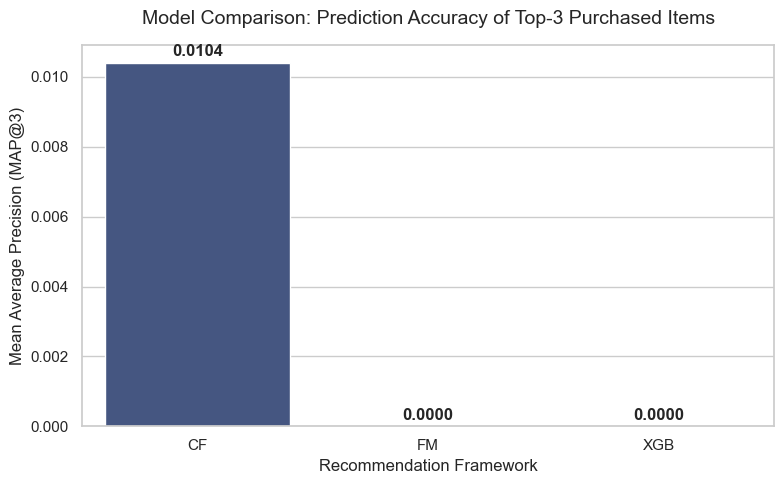

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot MAP@3 scores
ax = sns.barplot(x=results_df.columns, y=results_df.loc['MAP@3'], palette="viridis")
plt.title('Model Comparison: Prediction Accuracy of Top-3 Purchased Items', fontsize=14, pad=15)
plt.ylabel('Mean Average Precision (MAP@3)', fontsize=12)
plt.xlabel('Recommendation Framework', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [81]:
def get_cf_top_30_with_scores(original_visitorid):
    if original_visitorid not in original_visitorid_to_idx:
        return []

    visitor_idx = original_visitorid_to_idx[original_visitorid]
    user_interaction_vector = sparse_user_item[visitor_idx]

    # Model returns both internal IDs and their raw proximity scores
    ids, scores = cf_model.recommend(
        visitor_idx,
        user_interaction_vector,
        N=30,
        filter_already_liked_items=False
    )
    
    # Pair the decoded storefront item ID with its raw CF score
    return [
        (idx_to_original_itemid[item_idx], float(score)) 
        for item_idx, score in zip(ids, scores)
    ]

In [83]:
# 1. Fetch unique users
all_users = pd.Series(event_data['visitorid'].unique())

# 2. Build a temporary DataFrame containing the list of tuples
df_tuples = pd.DataFrame({
    'visitorid': all_users, 
    'pairs': all_users.apply(get_cf_top_30_with_scores)
})

# 3. Explode the lists of tuples vertically
df_tuples = df_tuples.explode('pairs')

# 4. Drop rows for any users that returned no candidates
df_tuples = df_tuples.dropna(subset=['pairs'])

# 5. Split the tuples into two separate columns
df_tuples['itemid'] = df_tuples['pairs'].apply(lambda x: x[0])
df_tuples['cf_score'] = df_tuples['pairs'].apply(lambda x: x[1])

# Drop the temporary 'pairs' column now that it's unpacked
top_300_items_per_user = df_tuples.drop(columns=['pairs'])

In [ ]:
# 2. Correctly aggregate purchases without dropping the ID indices
did_user_buy_item = event_data.groupby(['visitorid', 'itemid'])['transaction'].sum().reset_index()
did_user_buy_item['transaction'] = (did_user_buy_item['transaction'] > 0).astype(int)

# 3. Merge candidates with your binary purchase targets
# A left join ensures we keep all 300 candidates; users who didn't buy a candidate get NaN
candidate_user_item_pairs = pd.merge(
    left=X_train_stage2_per_user, 
    right=did_user_buy_item, 
    on=['visitorid', 'itemid'], 
    how='left'
)

# 4. Crucial Step: Fill NaN targets with 0 (No purchase occurred)
candidate_user_item_pairs['transaction'] = candidate_user_item_pairs['transaction'].fillna(0).astype(int)

# 5. Bring in item properties seamlessly using the clean 'itemid' column
candidate_user_item_pairs = pd.merge(
    left=candidate_user_item_pairs, 
    right=item_properties, 
    on='itemid', 
    how='left'
)

candidate_user_item_pairs.head()

,visitorid,itemid,cf_score,transaction,timestamp,112,159,202,283,364,6,678,764,776,790,888,917,available,categoryid
0,2.0,29940.0,0.034869,0,2015-06-28 03:00:00,679677,519769,961487 755772 350564 n1980.000,36842 295499 961487 755772 350564 n1980.000,30081,36842,295499,1285872,1328645,n50160.000,961487 755772 350564 n1980.000 961511,961487 755772 533005 415451,1,299
1,2.0,29940.0,0.034869,0,2015-07-05 03:00:00,679677,519769,961487 755772 350564 n1980.000,36842 295499 961487 755772 350564 n1980.000,30081,36842,295499,1285872,1328645,n50160.000,961487 755772 350564 n1980.000 961511,961487 755772 533005 415451,1,299
2,2.0,29940.0,0.034869,0,2015-07-12 03:00:00,679677,519769,961487 755772 350564 n1980.000,36842 295499 961487 755772 350564 n1980.000,30081,36842,295499,1285872,1328645,n59880.000,961487 755772 350564 n1980.000 961511,961487 755772 533005 415451,1,299
3,2.0,29940.0,0.034869,0,2015-07-19 03:00:00,679677,519769,961487 755772 350564 n1980.000,36842 295499 961487 755772 350564 n1980.000,30081,36842,295499,1285872,1328645,n59880.000,961487 755772 350564 n1980.000 961511,961487 755772 533005 415451,1,299
4,2.0,29940.0,0.034869,0,2015-07-26 03:00:00,679677,519769,961487 755772 350564 n1980.000,36842 295499 961487 755772 350564 n1980.000,30081,36842,295499,1285872,1328645,n59880.000,961487 755772 350564 n1980.000 961511,961487 755772 533005 415451,1,299


In [87]:
from xgboost import XGBRanker

# 1. Ensure the dataset is perfectly sorted by user so groups are contiguous
candidate_user_item_pairs = candidate_user_item_pairs.sort_values('visitorid').reset_index(drop=True)

if 'timestamp' in candidate_user_item_pairs.columns:
    candidate_user_item_pairs = candidate_user_item_pairs.drop(columns=['timestamp'])

for col in candidate_user_item_pairs.columns:
    if col not in ['visitorid', 'itemid', 'cf_score', 'transaction']:
        candidate_user_item_pairs[col] = candidate_user_item_pairs[col].astype('category')
# ------------------------------------------------

# 2. Extract targets and features from the sorted data
y_train = candidate_user_item_pairs['transaction']
X_train_stage2 = candidate_user_item_pairs.drop(columns=['visitorid', 'itemid', 'transaction'])

# 3. Calculate group sizes
groups = candidate_user_item_pairs.groupby('visitorid').size().values

# 4. Initialize and fit the ranking model
xgb_ranker = XGBRanker(
    objective="rank:ndcg",  # Optimizes the relative position of the items
    n_estimators=100,
    learning_rate=0.1,
    enable_categorical=True,  # Allows native handling of your category columns
    tree_method='hist'       # Оптимизация под низкое потребление памяти
)

xgb_ranker.fit(
    X_train_stage2, 
    y_train, 
    group=groups
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [114]:
def pipeline_get_3_items(original_visitorid, user_context_dict):
    # 1. Fetch the tuples from Stage 1
    tuples_list = get_cf_top_30_with_scores(original_visitorid)
    if not tuples_list:
        return []
        
    # Unpack tuples into separate lists for IDs and Scores
    top_30_items = [t[0] for t in tuples_list]
    cf_scores = [t[1] for t in tuples_list]

    # 2. Build the Candidate Dataframe
    candidate_df = pd.DataFrame({
        'itemid': top_30_items,
        'cf_score': cf_scores  # Match the exact feature name used in training!
    })
    candidate_df['visitorid'] = original_visitorid

    if hasattr(xgb_ranker, 'feature_names') and xgb_ranker.feature_names is not None:
        xgb_model_features = xgb_ranker.feature_names
    elif 'X_train_stage2' in globals():
        xgb_model_features = X_train_stage2.columns.tolist()
    else:
        xgb_model_features = [col.replace('prop_', '') for col in user_context_dict.keys()]
    
    # --- БЛОК ИСПРАВЛЕНИЯ ИМЕН И НАБОРА КОЛОНОК ---
    rename_dict = {}
    for col in candidate_df.columns:
        if col.startswith('prop_'):
            clean_name = col.replace('prop_', '')
            rename_dict[col] = clean_name
    candidate_df = candidate_df.rename(columns=rename_dict)
    
    for col in xgb_model_features:
        if col not in candidate_df.columns:
            candidate_df[col] = np.nan
            
    # --- ПРИВЕДЕНИЕ ТИПОВ ДАННЫХ (БЕЗОПАСНАЯ ВЕРСИЯ ДЛЯ PANDAS) ---
    for col in xgb_model_features:
        target_dtype = None
        if 'X_train_stage2' in globals() and col in X_train_stage2.columns:
            target_dtype = X_train_stage2[col].dtype
            
        if target_dtype is not None:
            # ИСПОЛЬЗУЕМ БЕЗОПАСНЫЙ ИНСТРУМЕНТ ИЗ PANDAS ВМЕСТО NUMPY
            if pd.api.types.is_integer_dtype(target_dtype):
                candidate_df[col] = candidate_df[col].fillna(0).astype(target_dtype)
            else:
                candidate_df[col] = candidate_df[col].astype(target_dtype)
            
    # --- ВЫПОЛНЕНИЕ РАНЖИРОВАНИЯ ---
    preds = xgb_ranker.predict(candidate_df[xgb_model_features])
    
    top_3_indices = np.argsort(-preds)[:3]
    return candidate_df.iloc[top_3_indices]['itemid'].tolist()
    #return [top_300_items[idx] for idx in top_3_indices]

In [115]:
for col_to_drop in ['visitorid', 'itemid', 'transaction']:
    if col_to_drop in X_train_stage2.columns:
        X_train_stage2 = X_train_stage2.drop(columns=[col_to_drop])

for col in X_train_stage2.columns:
    if X_train_stage2[col].dtype == 'object':
        X_train_stage2[col] = X_train_stage2[col].astype('category')
# ---------------------------------------------------

# Теперь можно смело делать предсказание:
scores = xgb_ranker.predict(X_train_stage2)

In [116]:
metrics['Pipe'] = []

for u in eval_users:
    actual = test_purchases[test_purchases['visitorid'] == u]['itemid'].tolist()

    if u in user_context_map:
        user_specific_context = user_context_map[u]
        pipeline_recs = pipeline_get_3_items(u, user_specific_context)
        metrics['Pipe'].append(apk3(actual, pipeline_recs))
    else:
        metrics['Pipe'].append(0.0)
        
results_df = pd.DataFrame({model: [np.mean(scores)] for model, scores in metrics.items()}, index=['MAP@3'])
results_df

,CF,FM,XGB,Pipe
MAP@3,0.010398,0.0,0.0,0.007339


C:\Users\New\AppData\Local\Temp\ipykernel_3320\1884932303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df.columns, y=results_df.loc['MAP@3'], palette="viridis")


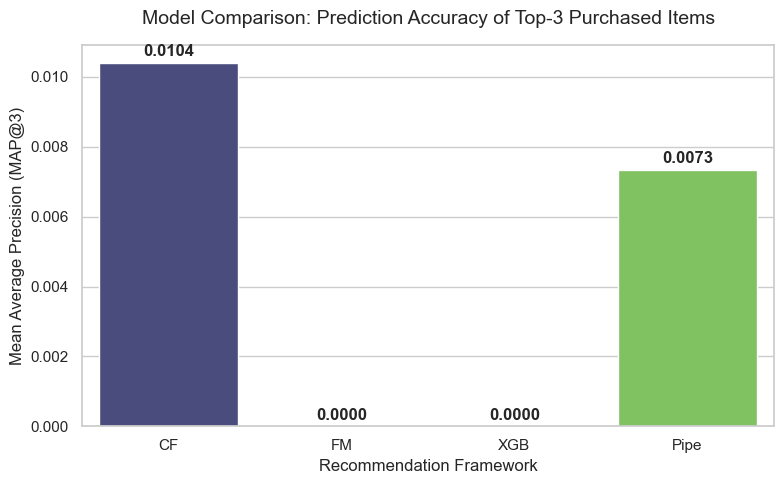

In [117]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot MAP@3 scores
ax = sns.barplot(x=results_df.columns, y=results_df.loc['MAP@3'], palette="viridis")
plt.title('Model Comparison: Prediction Accuracy of Top-3 Purchased Items', fontsize=14, pad=15)
plt.ylabel('Mean Average Precision (MAP@3)', fontsize=12)
plt.xlabel('Recommendation Framework', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [119]:
import pickle
import os

# Запоминаем типы данных колонок прямо внутри объекта модели
xgb_ranker.X_train_dtypes = X_train_stage2.dtypes

# Создаем папку для моделей, если её ещё нет
os.makedirs('models', exist_ok=True)

# 1. Сохраняем XGBRanker
with open('models/xgb_ranker.pkl', 'wb') as f:
    pickle.dump(xgb_ranker, f)
print("Модель XGBRanker успешно сохранена в models/xgb_ranker.pkl")

# 2. Сохраняем модель коллаборативной фильтрации (Stage 1)
# Укажи точное имя переменной твоей CF-модели (например, cf_model)
if 'cf_model' in globals():
    with open('models/cf_model.pkl', 'wb') as f:
        pickle.dump(cf_model, f)
    print("CF-модель успешно сохранена в models/cf_model.pkl")
else:
    print("Предупреждение: Переменная 'cf_model' не найдена. Проверь имя переменной.")

# 3. Сохраняем словарь контекста пользователей
if 'user_context_map' in globals():
    with open('models/user_context_map.pkl', 'wb') as f:
        pickle.dump(user_context_map, f)
    print("Контекст пользователей успешно сохранен в models/user_context_map.pkl")
else:
    print("Предупреждение: Переменная 'user_context_map' не найдена. Проверь имя переменной.")

Модель XGBRanker успешно сохранена в models/xgb_ranker.pkl
CF-модель успешно сохранена в models/cf_model.pkl
Контекст пользователей успешно сохранен в models/user_context_map.pkl


In [ ]:
with open('models/original_visitorid_to_idx.pkl', 'wb') as f:
    pickle.dump(original_visitorid_to_idx, f)
print("Маппинг пользователей успешно сохранен!")

with open('models/idx_to_original_itemid.pkl', 'wb') as f:
    pickle.dump(idx_to_original_itemid, f)
print("Маппинг товаров успешно сохранен!")

with open('models/sparse_user_item.pkl', 'wb') as f:
    pickle.dump(sparse_user_item, f)
print("Разреженная csr-матрица пользователей-товаров сохранена!")

Маппинг пользователей успешно сохранен!
Маппинг товаров успешно сохранен!
Разреженная csr-матрица юзеров сохранена!
